# Phase 11: Fair OSP vs Learnable Pipeline

Goal: run fixed OSP and OSP-seeded learnable MSFA in one notebook with fair settings:
- same dataset
- same UNet
- same epoch budget and loop structure
- explicit evaluation, visualization, and result table


# Learnable MSFA Research Track

This notebook is part of the 10-day publication-oriented extension track.

## Run discipline
- Keep one experiment purpose per notebook.
- Save metrics and checkpoints to the configured project root.
- Do not silently change data splits or loss definitions across notebooks.
- When a result becomes final, export both numeric artifacts and a figure/table asset.


In [1]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Google Drive mounted.")
except Exception as exc:
    print("Drive mount skipped:", exc)


Mounted at /content/drive
Google Drive mounted.


In [2]:
import csv
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

SEED = 42
PROJECT_ROOT = Path("/content/drive/MyDrive/Msa-Osp")
PATCH_PATH = PROJECT_ROOT / "dataset_patches.npz"
OSP_REFINE_CKPT_PATH = PROJECT_ROOT / "learned_osp_selector_refine_best.pth"
OSP_SELECTOR_CKPT_PATH = PROJECT_ROOT / "learned_osp_selector_best.pth"
LEARNED3D_CKPT_PATH = PROJECT_ROOT / "learned_msfa_3dsp_best.pth"
BASELINE_CKPT_PATH = PROJECT_ROOT / "unet_baseline_best.pth"
# Notebook run mode.
MODE = "both"  # options: "osp", "learnable", "both"

HISTORY_OSP_PATH = PROJECT_ROOT / "phase11_osp_history.csv"
HISTORY_EXACT_PATH = PROJECT_ROOT / "phase11_exact_selector_history.csv"
HISTORY_LEARN_PATH = PROJECT_ROOT / "phase11_learnable_history.csv"
CKPT_OSP_PATH = PROJECT_ROOT / "phase11_osp_best.pth"
CKPT_EXACT_PATH = PROJECT_ROOT / "phase11_exact_selector_best.pth"
CKPT_LEARN_PATH = PROJECT_ROOT / "phase11_learnable_best.pth"
TILE_LEARN_SOFT_PATH = PROJECT_ROOT / "phase11_learnable_tile_soft.npy"
SNAPSHOT_DIR = PROJECT_ROOT / "phase11_tile_snapshots"
FIG_DIR = PROJECT_ROOT / "phase11_figures"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 8
EPOCHS = 72
SELECTOR_EPOCHS = 30
EXACT_REFINE_EPOCHS = 12
UNET_LR = 1.5e-4
MSFA_LR = 5e-4
SELECTOR_LR = 1.5e-2
EXACT_REFINE_LR = 5e-5
BAND_COUNT = 16
TILE_SIZE = 16
BASE = 32
TEMP_START = 1.00
TEMP_END = 0.20
SELECTOR_TEMP_START = 2.0
SELECTOR_TEMP_END = 0.25
SELECTOR_REHEAT_START = 14
SELECTOR_REHEAT_LENGTH = 4
SELECTOR_REHEAT_TEMP = 1.0
INIT_LOGIT_BOOST = 2.0
DELTA_INIT_STD = 5e-2
PRIOR_SCALE_START = 1.00
PRIOR_SCALE_END = 0.30
PRIOR_RELEASE_EPOCHS = 28
SAM_WEIGHT = 5e-2
LAMBDA_SP = 1e-3
LAMBDA_ROWCOL = 2e-3
LAMBDA_DELTA = 5e-6
LAMBDA_ENT_EXPLORE = -1.0e-3
LAMBDA_ENT_FINAL = 7e-4
LAMBDA_ESCAPE = 2e-2
ESCAPE_EPOCHS = 18
TARGET_MATCH_START = 0.98
TARGET_MATCH_END = 0.88
D_MIN_3D = 0.55
Z_WEIGHT = 1.25
GRAD_WEIGHT = 1e-2
SPEC_WEIGHT = 2e-2
LAMBDA_SCORE = 5e-2
LAMBDA_SELECTOR_ENT = 2e-3
DISTILL_WEIGHT_START = 5e-2
DISTILL_WEIGHT_END = 0.0
CKPT_SCORE_SAM_WEIGHT = 0.15
MIN_LR = 1e-5
EARLY_STOP_PATIENCE = 9

try:
    from skimage.metrics import structural_similarity as ssim_fn
    HAS_SSIM = True
except Exception:
    HAS_SSIM = False

print("Device:", DEVICE)
print("MODE:", MODE)
print("SEED:", SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


Device: cuda
MODE: both
SEED: 42


In [3]:
data = np.load(PATCH_PATH)
train_target = data["train"]
val_target = data["val"]

class CubeDataset(Dataset):
    def __init__(self, cubes):
        self.cubes = cubes

    def __len__(self):
        return len(self.cubes)

    def __getitem__(self, idx):
        return torch.from_numpy(self.cubes[idx]).permute(2, 0, 1).float()

train_loader = DataLoader(CubeDataset(train_target), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(CubeDataset(val_target), batch_size=BATCH_SIZE, shuffle=False)


In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class UNet2D(nn.Module):
    def __init__(self, in_ch=1, out_ch=16, base=BASE):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(base, base * 2)
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(base * 2, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)
        self.final = nn.Conv2d(base, out_ch, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))
        d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.final(d1)

def compute_psnr(pred, target, eps=1e-8):
    mse = torch.mean((pred - target) ** 2)
    return 20 * torch.log10(1.0 / torch.sqrt(mse + eps))

def spectral_angle_mapper(pred, target, eps=1e-8):
    dot = torch.sum(pred * target, dim=1)
    pred_norm = torch.norm(pred, dim=1)
    target_norm = torch.norm(target, dim=1)
    cos_theta = torch.clamp(dot / (pred_norm * target_norm + eps), -1 + eps, 1 - eps)
    return torch.rad2deg(torch.acos(cos_theta)).mean()

def spectral_angle_loss(pred, target, eps=1e-8):
    dot = torch.sum(pred * target, dim=1)
    pred_norm = torch.norm(pred, dim=1)
    target_norm = torch.norm(target, dim=1)
    cos_theta = torch.clamp(dot / (pred_norm * target_norm + eps), -1 + eps, 1 - eps)
    return torch.acos(cos_theta).mean()

def compute_rgb_ssim(pred, target):
    if not HAS_SSIM:
        return float("nan")
    pred_np = pred.detach().cpu().numpy()
    target_np = target.detach().cpu().numpy()
    scores = []
    for i in range(pred_np.shape[0]):
        p = np.transpose(pred_np[i, [5, 10, 15]], (1, 2, 0))
        t = np.transpose(target_np[i, [5, 10, 15]], (1, 2, 0))
        data_range = max(float(t.max() - t.min()), 1e-8)
        scores.append(ssim_fn(t, p, data_range=data_range, channel_axis=2))
    return float(np.mean(scores))

def spatial_gradient_loss(pred, target):
    pred_dx = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    pred_dy = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    target_dx = target[:, :, :, 1:] - target[:, :, :, :-1]
    target_dy = target[:, :, 1:, :] - target[:, :, :-1, :]
    return F.l1_loss(pred_dx, target_dx) + F.l1_loss(pred_dy, target_dy)

def spectral_gradient_consistency_loss(pred, target):
    pred_dlambda = pred[:, 1:, :, :] - pred[:, :-1, :, :]
    target_dlambda = target[:, 1:, :, :] - target[:, :-1, :, :]
    return F.l1_loss(pred_dlambda, target_dlambda)

def make_osp_tile(a, b, bands=BAND_COUNT, size=TILE_SIZE):
    # MATLAB DDDRSNNP3 convention: G = mod(I.*a + J.*b, NF) + 1 with I=row, J=col.
    row_idx = torch.arange(1, bands + 1, dtype=torch.int64).view(-1, 1).repeat(1, bands)
    col_idx = torch.arange(1, bands + 1, dtype=torch.int64).view(1, -1).repeat(bands, 1)
    base = torch.remainder(row_idx * int(a) + col_idx * int(b), bands) + 1
    if size == bands:
        return base
    reps = math.ceil(size / bands)
    return base.repeat(reps, reps)[:size, :size]

def osp_min_distance_score(tile):
    y, x = torch.meshgrid(
        torch.arange(1, tile.shape[0] + 1, dtype=torch.float32),
        torch.arange(1, tile.shape[1] + 1, dtype=torch.float32),
        indexing="ij",
    )
    points = torch.stack([y.reshape(-1), x.reshape(-1), tile.float().reshape(-1)], dim=1)
    return torch.pdist(points).min().item()

def search_dddrsnnp3_best_ab(bands=BAND_COUNT):
    m = round(bands / 2)
    distance = torch.zeros((m, m), dtype=torch.float64)
    for i in range(1, m + 1):
        for j in range(i, m + 1):
            tile_ij = make_osp_tile(i, j, bands=bands, size=bands)
            if len(torch.unique(tile_ij)) != bands:
                continue
            distance[i - 1, j - 1] = osp_min_distance_score(tile_ij)
    best = float(distance.max().item())
    if best <= 0.0:
        raise RuntimeError("No valid OSP candidate available for the current BAND_COUNT.")
    # MATLAB tie-break: [b,a]=find(ma==distance); pick first in column-major order.
    tol = 1e-12
    for col in range(m):
        for row in range(m):
            if abs(float(distance[row, col].item()) - best) <= tol:
                b = row + 1
                a = col + 1
                return (a, b), best
    raise RuntimeError("Failed to resolve MATLAB tie-break for OSP search.")

def build_candidate_bank():
    rows = []
    m = round(BAND_COUNT / 2)
    for i in range(1, m + 1):
        for j in range(i, m + 1):
            base = make_osp_tile(i, j, bands=BAND_COUNT, size=BAND_COUNT)
            if len(torch.unique(base)) != BAND_COUNT:
                continue
            # Match MATLAB output naming: [b,a]=find(...); G uses (a,b).
            a = int(j)
            b = int(i)
            rows.append((a, b, make_osp_tile(a, b, bands=BAND_COUNT, size=TILE_SIZE)))
    return rows

def choose_osp_reference():
    (a, b), _ = search_dddrsnnp3_best_ab(BAND_COUNT)
    return make_osp_tile(a, b), (a, b), "dddrsnnp3_matlab_tiebreak"

candidate_records = []
for a, b, tile in build_candidate_bank():
    candidate_records.append(
        {
            "a": int(a),
            "b": int(b),
            "tile": tile,
            "score_raw": osp_min_distance_score(make_osp_tile(a, b, bands=BAND_COUNT, size=BAND_COUNT))
        }
    )
if not candidate_records:
    raise RuntimeError("No OSP candidates were generated for ExactOSPSelector.")

candidate_tiles = torch.stack(
    [F.one_hot((rec["tile"] - 1).long(), num_classes=BAND_COUNT).permute(2, 0, 1).float() for rec in candidate_records],
    dim=0,
)
candidate_scores_raw = torch.tensor([rec["score_raw"] for rec in candidate_records], dtype=torch.float32)
candidate_scores_norm = (candidate_scores_raw - candidate_scores_raw.min()) / (
    candidate_scores_raw.max() - candidate_scores_raw.min() + 1e-8
)
candidate_ab = torch.tensor([[rec["a"], rec["b"]] for rec in candidate_records], dtype=torch.int64)

init_tile_one_based, init_ab, init_source = choose_osp_reference()
print("OSP reference source:", init_source)
print("OSP reference (a,b):", init_ab)

class FixedOSP(nn.Module):
    def __init__(self, init_tile_one_based):
        super().__init__()
        init_tile_zero_based = init_tile_one_based.long() - 1
        onehot = F.one_hot(init_tile_zero_based, num_classes=BAND_COUNT).permute(2, 0, 1).float()
        self.register_buffer("weights", onehot)
        self.register_buffer("init_tile_one_based", init_tile_one_based.long())

    def soft_tile(self, temp=None, prior_scale=None):
        return self.weights

    def hard_tile(self, temp=None, prior_scale=None):
        return self.init_tile_one_based

    def forward(self, x, temp=None, prior_scale=None):
        _, _, h, w = x.shape
        weights_full = self.weights.repeat(1, h // TILE_SIZE, w // TILE_SIZE)
        return (x * weights_full.unsqueeze(0)).sum(dim=1, keepdim=True)

class OSPSeededLearnableMSFA(nn.Module):
    def __init__(self, init_tile_one_based):
        super().__init__()
        init_tile_zero_based = init_tile_one_based.long() - 1
        prior = F.one_hot(init_tile_zero_based, num_classes=BAND_COUNT).permute(2, 0, 1).float()
        prior_logits = torch.full_like(prior, -INIT_LOGIT_BOOST)
        prior_logits = prior_logits + prior * (2.0 * INIT_LOGIT_BOOST)
        self.register_buffer("prior_logits", prior_logits)
        self.register_buffer("init_tile_one_based", init_tile_one_based.long())
        self.register_buffer("init_onehot", prior)
        self.delta_logits = nn.Parameter(DELTA_INIT_STD * torch.randn_like(prior_logits))

    def logits(self, prior_scale=1.0):
        return prior_scale * self.prior_logits + self.delta_logits

    def soft_tile(self, temp, prior_scale=1.0):
        return torch.softmax(self.logits(prior_scale=prior_scale) / temp, dim=0)

    def hard_tile(self, temp=TEMP_END, prior_scale=PRIOR_SCALE_END):
        return self.soft_tile(temp=temp, prior_scale=prior_scale).argmax(dim=0) + 1

    def forward(self, x, temp, prior_scale=1.0):
        _, _, h, w = x.shape
        weights = self.soft_tile(temp=temp, prior_scale=prior_scale)
        weights_full = weights.repeat(1, h // TILE_SIZE, w // TILE_SIZE)
        return (x * weights_full.unsqueeze(0)).sum(dim=1, keepdim=True)

class ExactOSPSelector(nn.Module):
    def __init__(self, candidate_tiles, candidate_scores_raw, candidate_scores_norm, candidate_ab):
        super().__init__()
        self.register_buffer("candidate_tiles", candidate_tiles)
        self.register_buffer("candidate_scores_raw", candidate_scores_raw)
        self.register_buffer("candidate_scores_norm", candidate_scores_norm)
        self.register_buffer("candidate_ab", candidate_ab)
        self.logits = nn.Parameter(0.25 * candidate_scores_norm.clone())

    def probs(self, temp, training=True):
        if training:
            return F.gumbel_softmax(self.logits, tau=temp, hard=False, dim=0)
        return torch.softmax(self.logits / temp, dim=0)

    def soft_tile(self, temp, training=True):
        probs = self.probs(temp=temp, training=training)
        return torch.sum(probs.view(-1, 1, 1, 1) * self.candidate_tiles, dim=0)

    def hard_index(self):
        return int(torch.argmax(self.logits).item())

    def hard_tile(self):
        return self.candidate_tiles[self.hard_index()].argmax(dim=0) + 1

    def selected_ab(self):
        idx = self.hard_index()
        a, b = self.candidate_ab[idx].tolist()
        return idx, (int(a), int(b))

    def selected_score(self):
        return float(self.candidate_scores_raw[self.hard_index()].item())

    def selector_entropy(self, temp, training=True, eps=1e-8):
        probs = self.probs(temp=temp, training=training)
        return -(probs * torch.log(probs + eps)).sum()

    def expected_score(self, temp, training=True):
        probs = self.probs(temp=temp, training=training)
        return torch.sum(probs * self.candidate_scores_norm)

    def forward(self, x, temp, training=True):
        _, _, h, w = x.shape
        weights = self.soft_tile(temp=temp, training=training)
        weights_full = weights.repeat(1, h // TILE_SIZE, w // TILE_SIZE)
        return (x * weights_full.unsqueeze(0)).sum(dim=1, keepdim=True)

spatial_coords = torch.stack(
    torch.meshgrid(
        torch.linspace(0.0, 1.0, TILE_SIZE),
        torch.linspace(0.0, 1.0, TILE_SIZE),
        indexing="ij",
    ),
    dim=-1,
).reshape(-1, 2)
wavelength_coords = torch.linspace(0.0, 1.0, BAND_COUNT)

def osp_3d_points(msfa, temp, prior_scale):
    soft_tile = msfa.soft_tile(temp=temp, prior_scale=prior_scale)
    z = (soft_tile * wavelength_coords.to(soft_tile.device).view(BAND_COUNT, 1, 1)).sum(dim=0).reshape(-1, 1)
    xy = spatial_coords.to(soft_tile.device)
    return torch.cat([xy, Z_WEIGHT * z], dim=1)

def osp_3d_loss(msfa, temp, prior_scale):
    points = osp_3d_points(msfa, temp, prior_scale)
    d = torch.cdist(points, points, p=2)
    mask = torch.triu(torch.ones_like(d), diagonal=1) > 0
    distances = d[mask]
    return torch.relu(D_MIN_3D - distances).mean()

def distance_stats(msfa, temp, prior_scale):
    points = osp_3d_points(msfa, temp, prior_scale)
    d = torch.cdist(points, points, p=2)
    mask = torch.triu(torch.ones_like(d), diagonal=1) > 0
    distances = d[mask]
    return {
        "min_3d_distance": distances.min().item(),
        "mean_3d_distance": distances.mean().item(),
    }

def rowcol_uniformity_loss(msfa, temp, prior_scale):
    soft_tile = msfa.soft_tile(temp=temp, prior_scale=prior_scale)
    row_counts = soft_tile.sum(dim=2)
    col_counts = soft_tile.sum(dim=1)
    target_row = torch.ones_like(row_counts)
    target_col = torch.ones_like(col_counts)
    return ((row_counts - target_row) ** 2).mean() + ((col_counts - target_col) ** 2).mean()

def delta_regularization(msfa):
    return msfa.delta_logits.pow(2).mean()

def entropy_loss(msfa, temp, prior_scale, eps=1e-8):
    soft_tile = msfa.soft_tile(temp=temp, prior_scale=prior_scale)
    return -(soft_tile * torch.log(soft_tile + eps)).sum(dim=0).mean()

def seed_match(msfa, temp, prior_scale):
    soft_tile = msfa.soft_tile(temp=temp, prior_scale=prior_scale)
    return (soft_tile * msfa.init_onehot).sum(dim=0).mean()

def escape_from_seed_loss(msfa, temp, prior_scale, epoch):
    if epoch > ESCAPE_EPOCHS:
        return torch.zeros((), device=msfa.delta_logits.device)
    progress = (epoch - 1) / max(ESCAPE_EPOCHS - 1, 1)
    target_match = TARGET_MATCH_START + progress * (TARGET_MATCH_END - TARGET_MATCH_START)
    return torch.relu(seed_match(msfa, temp=temp, prior_scale=prior_scale) - target_match)

def changed_fraction(msfa, temp, prior_scale):
    hard_tile = msfa.hard_tile(temp=temp, prior_scale=prior_scale)
    return (hard_tile != msfa.init_tile_one_based).float().mean().item()

def try_load_unet_weights(model):
    for path in [BASELINE_CKPT_PATH, OSP_REFINE_CKPT_PATH, OSP_SELECTOR_CKPT_PATH, LEARNED3D_CKPT_PATH]:
        if not path.exists():
            continue
        checkpoint = torch.load(path, map_location="cpu", weights_only=False)
        state = None
        if "model" in checkpoint:
            state = checkpoint["model"]
        elif "unet" in checkpoint:
            state = checkpoint["unet"]
        elif "model_state_dict" in checkpoint:
            state = checkpoint["model_state_dict"]
        if state is None:
            continue
        try:
            model.load_state_dict(state, strict=True)
            print("Loaded UNet weights from:", path.name)
            return path.name
        except Exception:
            continue
    print("UNet warm-start skipped.")
    return None

def evaluate(msfa, model, dataloader, mode_name, temp=TEMP_END, prior_scale=PRIOR_SCALE_END):
    model.eval()
    msfa.eval()
    psnr_total = 0.0
    sam_total = 0.0
    ssim_total = 0.0
    with torch.no_grad():
        for x in dataloader:
            x = x.to(DEVICE)
            if mode_name == "learnable":
                sensed = msfa(x, temp=temp, prior_scale=prior_scale)
            else:
                sensed = msfa(x)
            pred = model(sensed)
            psnr_total += compute_psnr(pred, x).item()
            sam_total += spectral_angle_mapper(pred, x).item()
            ssim_total += compute_rgb_ssim(pred, x)
    n = len(dataloader)
    return psnr_total / n, sam_total / n, ssim_total / n


OSP reference source: learned_osp_selector_refine_best.pth
OSP reference (a,b): (3, 5)


In [7]:
def temperature(epoch):
    return TEMP_START + (TEMP_END - TEMP_START) * (epoch - 1) / max(EPOCHS - 1, 1)

def prior_scale(epoch):
    if epoch >= PRIOR_RELEASE_EPOCHS:
        return PRIOR_SCALE_END
    return PRIOR_SCALE_START + (PRIOR_SCALE_END - PRIOR_SCALE_START) * (epoch - 1) / max(PRIOR_RELEASE_EPOCHS - 1, 1)

def rowcol_weight(epoch):
    progress = (epoch - 1) / max(EPOCHS - 1, 1)
    return LAMBDA_ROWCOL * max(0.0, min(1.0, (progress - 0.20) / 0.35))

def delta_weight(epoch):
    progress = (epoch - 1) / max(EPOCHS - 1, 1)
    return LAMBDA_DELTA * max(0.0, min(1.0, (progress - 0.55) / 0.25))

def entropy_weight(epoch):
    progress = (epoch - 1) / max(EPOCHS - 1, 1)
    if progress <= 0.40:
        return LAMBDA_ENT_EXPLORE
    ramp = min(1.0, (progress - 0.40) / 0.60)
    return LAMBDA_ENT_EXPLORE + ramp * (LAMBDA_ENT_FINAL - LAMBDA_ENT_EXPLORE)

def selector_temperature(epoch):
    base = SELECTOR_TEMP_START + (SELECTOR_TEMP_END - SELECTOR_TEMP_START) * (epoch - 1) / max(SELECTOR_EPOCHS - 1, 1)
    if SELECTOR_REHEAT_START <= epoch < SELECTOR_REHEAT_START + SELECTOR_REHEAT_LENGTH:
        frac = (epoch - SELECTOR_REHEAT_START) / max(SELECTOR_REHEAT_LENGTH - 1, 1)
        return SELECTOR_REHEAT_TEMP + frac * (base - SELECTOR_REHEAT_TEMP)
    return base

def distill_weight(epoch):
    progress = (epoch - 1) / max(EPOCHS - 1, 1)
    return DISTILL_WEIGHT_START + progress * (DISTILL_WEIGHT_END - DISTILL_WEIGHT_START)

def save_epoch_tile(msfa, mode_name, epoch, temp, pscale):
    SNAPSHOT_DIR.mkdir(parents=True, exist_ok=True)
    mode_dir = SNAPSHOT_DIR / mode_name
    mode_dir.mkdir(parents=True, exist_ok=True)
    if mode_name == "learnable":
        tile = msfa.hard_tile(temp=temp, prior_scale=pscale).detach().cpu().numpy()
    elif mode_name == "exact_selector":
        tile = msfa.hard_tile().detach().cpu().numpy()
    else:
        tile = msfa.hard_tile().detach().cpu().numpy()
    np.save(mode_dir / f"hard_tile_epoch_{epoch:03d}.npy", tile)

def load_model_state_if_present(model, state_dict):
    if state_dict is not None:
        model.load_state_dict(state_dict, strict=True)
        return "inline_warm_start"
    return try_load_unet_weights(model)

def train_exact_selector(model_state=None):
    model = UNet2D().to(DEVICE)
    warm_start_source = load_model_state_if_present(model, model_state)
    selector = ExactOSPSelector(
        candidate_tiles=candidate_tiles.to(DEVICE),
        candidate_scores_raw=candidate_scores_raw.to(DEVICE),
        candidate_scores_norm=candidate_scores_norm.to(DEVICE),
        candidate_ab=candidate_ab.to(DEVICE),
    ).to(DEVICE)
    optimizer = torch.optim.Adam(
        [{"params": model.parameters(), "lr": UNET_LR}, {"params": selector.parameters(), "lr": SELECTOR_LR}]
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=SELECTOR_EPOCHS, eta_min=MIN_LR)
    criterion = nn.L1Loss()
    best_psnr = -float("inf")
    best_quality = -float("inf")
    epochs_since_improve = 0
    history = []

    for epoch in range(1, SELECTOR_EPOCHS + 1):
        temp = selector_temperature(epoch)
        model.train()
        selector.train()
        train_loss = 0.0
        train_psnr = 0.0
        for x in train_loader:
            x = x.to(DEVICE)
            pred = model(selector(x, temp=temp, training=True))
            recon_l1 = criterion(pred, x)
            recon_sam = spectral_angle_loss(pred, x)
            recon_grad = spatial_gradient_loss(pred, x)
            recon_spec = spectral_gradient_consistency_loss(pred, x)
            score_loss = -selector.expected_score(temp=temp, training=True)
            ent_loss = selector.selector_entropy(temp=temp, training=True)
            loss = (
                recon_l1
                + SAM_WEIGHT * recon_sam
                + GRAD_WEIGHT * recon_grad
                + SPEC_WEIGHT * recon_spec
                + LAMBDA_SCORE * score_loss
                + LAMBDA_SELECTOR_ENT * ent_loss
            )
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_psnr += compute_psnr(pred, x).item()

        model.eval()
        selector.eval()
        val_psnr = 0.0
        val_sam = 0.0
        with torch.no_grad():
            for x in val_loader:
                x = x.to(DEVICE)
                pred = model(selector(x, temp=temp, training=False))
                val_psnr += compute_psnr(pred, x).item()
                val_sam += spectral_angle_mapper(pred, x).item()

        train_loss /= len(train_loader)
        train_psnr /= len(train_loader)
        val_psnr /= len(val_loader)
        val_sam /= len(val_loader)
        quality = val_psnr - CKPT_SCORE_SAM_WEIGHT * val_sam
        selected_idx, (selected_a, selected_b) = selector.selected_ab()
        top_prob = selector.probs(temp=temp, training=False).max().item()
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "train_psnr": train_psnr,
                "val_psnr": val_psnr,
                "val_sam_deg": val_sam,
                "temperature": temp,
                "selected_index": selected_idx,
                "selected_a": selected_a,
                "selected_b": selected_b,
                "selected_score_raw": selector.selected_score(),
                "top_probability": top_prob,
            }
        )
        print(
            f"[exact] Epoch {epoch:02d} | train PSNR {train_psnr:.2f} dB | "
            f"val PSNR {val_psnr:.2f} dB | val SAM {val_sam:.2f} deg | "
            f"sel ({selected_a},{selected_b}) | top p {top_prob:.3f}"
        )
        scheduler.step()

        if epoch % 5 == 0:
            save_epoch_tile(selector, "exact_selector", epoch, temp=temp, pscale=1.0)

        if quality > best_quality:
            best_psnr = val_psnr
            best_quality = quality
            epochs_since_improve = 0
            torch.save(
                {
                    "epoch": epoch,
                    "model": model.state_dict(),
                    "selector": selector.state_dict(),
                    "best_val_psnr": best_psnr,
                    "best_quality": best_quality,
                    "temperature": temp,
                    "selected_index": selected_idx,
                    "selected_a": selected_a,
                    "selected_b": selected_b,
                    "selected_score_raw": selector.selected_score(),
                    "hard_tile": selector.hard_tile().detach().cpu().numpy(),
                    "warm_start_source": warm_start_source,
                },
                CKPT_EXACT_PATH,
            )
        else:
            epochs_since_improve += 1
            if epochs_since_improve >= EARLY_STOP_PATIENCE:
                print(f"[exact] Early stopping at epoch {epoch:02d}")
                break

    HISTORY_EXACT_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(HISTORY_EXACT_PATH, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(history[0].keys()))
        writer.writeheader()
        writer.writerows(history)

    exact_ckpt = torch.load(CKPT_EXACT_PATH, map_location=DEVICE, weights_only=False)
    selected_tile = torch.tensor(exact_ckpt["hard_tile"], dtype=torch.int64)
    selected_msfa = FixedOSP(init_tile_one_based=selected_tile).to(DEVICE)
    model.load_state_dict(exact_ckpt["model"], strict=True)

    refine_optimizer = torch.optim.Adam(model.parameters(), lr=EXACT_REFINE_LR)
    refine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(refine_optimizer, T_max=EXACT_REFINE_EPOCHS, eta_min=MIN_LR)
    refine_best_psnr = -float("inf")
    refine_best_quality = -float("inf")
    for epoch in range(1, EXACT_REFINE_EPOCHS + 1):
        model.train()
        for x in train_loader:
            x = x.to(DEVICE)
            pred = model(selected_msfa(x))
            loss = (
                criterion(pred, x)
                + SAM_WEIGHT * spectral_angle_loss(pred, x)
                + GRAD_WEIGHT * spatial_gradient_loss(pred, x)
                + SPEC_WEIGHT * spectral_gradient_consistency_loss(pred, x)
            )
            refine_optimizer.zero_grad()
            loss.backward()
            refine_optimizer.step()
        refine_scheduler.step()
        model.eval()
        val_psnr = 0.0
        val_sam = 0.0
        with torch.no_grad():
            for x in val_loader:
                x = x.to(DEVICE)
                pred = model(selected_msfa(x))
                val_psnr += compute_psnr(pred, x).item()
                val_sam += spectral_angle_mapper(pred, x).item()
        val_psnr /= len(val_loader)
        val_sam /= len(val_loader)
        quality = val_psnr - CKPT_SCORE_SAM_WEIGHT * val_sam
        print(
            f"[exact-refine] Epoch {epoch:02d} | val PSNR {val_psnr:.2f} dB | "
            f"val SAM {val_sam:.2f} deg"
        )
        if quality > refine_best_quality:
            refine_best_psnr = val_psnr
            refine_best_quality = quality
            exact_ckpt["model"] = model.state_dict()
            exact_ckpt["best_val_psnr"] = refine_best_psnr
            exact_ckpt["best_quality"] = refine_best_quality
            exact_ckpt["refined_val_sam_deg"] = val_sam
            torch.save(exact_ckpt, CKPT_EXACT_PATH)

    exact_ckpt = torch.load(CKPT_EXACT_PATH, map_location=DEVICE, weights_only=False)
    return {
        "selected_tile": torch.tensor(exact_ckpt["hard_tile"], dtype=torch.int64),
        "selected_ab": (int(exact_ckpt["selected_a"]), int(exact_ckpt["selected_b"])),
        "model_state": exact_ckpt["model"],
        "ckpt_path": str(CKPT_EXACT_PATH),
    }

def train_mode(mode_name, init_tile_for_mode=None, warm_model_state=None, teacher_bundle=None):
    assert mode_name in ["osp", "learnable"]
    history_path = HISTORY_OSP_PATH if mode_name == "osp" else HISTORY_LEARN_PATH
    ckpt_path = CKPT_OSP_PATH if mode_name == "osp" else CKPT_LEARN_PATH

    model = UNet2D().to(DEVICE)
    warm_start_source = load_model_state_if_present(model, warm_model_state)
    init_tile_local = init_tile_one_based if init_tile_for_mode is None else init_tile_for_mode
    if mode_name == "osp":
        msfa = FixedOSP(init_tile_one_based=init_tile_local).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=UNET_LR)
    else:
        msfa = OSPSeededLearnableMSFA(init_tile_one_based=init_tile_local).to(DEVICE)
        optimizer = torch.optim.Adam(
            [{"params": model.parameters(), "lr": UNET_LR}, {"params": msfa.delta_logits, "lr": MSFA_LR}]
        )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=MIN_LR)

    criterion = nn.L1Loss()
    best_psnr = -float("inf")
    best_quality = -float("inf")
    epochs_since_improve = 0
    history = []
    train_loss_list = []
    val_psnr_list = []

    for epoch in range(1, EPOCHS + 1):
        temp = temperature(epoch)
        pscale = prior_scale(epoch)
        rc_w = rowcol_weight(epoch)
        d_w = delta_weight(epoch)
        ent_w = entropy_weight(epoch)
        model.train()
        msfa.train()
        train_loss = 0.0
        train_psnr = 0.0

        for x in train_loader:
            x = x.to(DEVICE)
            sensed = msfa(x) if mode_name == "osp" else msfa(x, temp=temp, prior_scale=pscale)
            pred = model(sensed)
            recon_l1 = criterion(pred, x)
            recon_sam = spectral_angle_loss(pred, x)
            recon_grad = spatial_gradient_loss(pred, x)
            recon_spec = spectral_gradient_consistency_loss(pred, x)
            loss = recon_l1 + SAM_WEIGHT * recon_sam + GRAD_WEIGHT * recon_grad + SPEC_WEIGHT * recon_spec

            sp_loss = torch.zeros((), device=DEVICE)
            rc_loss = torch.zeros((), device=DEVICE)
            delta_loss = torch.zeros((), device=DEVICE)
            ent_loss = torch.zeros((), device=DEVICE)
            esc_loss = torch.zeros((), device=DEVICE)
            distill_loss = torch.zeros((), device=DEVICE)

            if mode_name == "learnable":
                sp_loss = osp_3d_loss(msfa, temp=temp, prior_scale=pscale)
                rc_loss = rowcol_uniformity_loss(msfa, temp=temp, prior_scale=pscale)
                delta_loss = delta_regularization(msfa)
                ent_loss = entropy_loss(msfa, temp=temp, prior_scale=pscale)
                esc_loss = escape_from_seed_loss(msfa, temp=temp, prior_scale=pscale, epoch=epoch)
                if teacher_bundle is not None:
                    with torch.no_grad():
                        teacher_pred = teacher_bundle["model"](teacher_bundle["msfa"](x))
                    distill_loss = F.smooth_l1_loss(pred, teacher_pred)
                loss = (
                    loss
                    + LAMBDA_SP * sp_loss
                    + rc_w * rc_loss
                    + d_w * delta_loss
                    + ent_w * ent_loss
                    + LAMBDA_ESCAPE * esc_loss
                    + distill_weight(epoch) * distill_loss
                )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_psnr += compute_psnr(pred, x).item()

        model.eval()
        msfa.eval()
        val_psnr = 0.0
        val_sam = 0.0
        with torch.no_grad():
            for x in val_loader:
                x = x.to(DEVICE)
                sensed = msfa(x) if mode_name == "osp" else msfa(x, temp=temp, prior_scale=pscale)
                pred = model(sensed)
                val_psnr += compute_psnr(pred, x).item()
                val_sam += spectral_angle_mapper(pred, x).item()

        train_loss /= len(train_loader)
        train_psnr /= len(train_loader)
        val_psnr /= len(val_loader)
        val_sam /= len(val_loader)
        quality = val_psnr - CKPT_SCORE_SAM_WEIGHT * val_sam
        train_loss_list.append(train_loss)
        val_psnr_list.append(val_psnr)

        if mode_name == "learnable":
            stats = distance_stats(msfa, temp=temp, prior_scale=pscale)
            seed_value = seed_match(msfa, temp=temp, prior_scale=pscale).item()
            soft_changed = 1.0 - seed_value
            hard_changed = changed_fraction(msfa, temp=temp, prior_scale=pscale)
        else:
            stats = {"min_3d_distance": float("nan"), "mean_3d_distance": float("nan")}
            seed_value = 1.0
            soft_changed = 0.0
            hard_changed = 0.0

        history.append(
            {
                "epoch": epoch,
                "mode": mode_name,
                "train_loss": train_loss,
                "train_psnr": train_psnr,
                "val_psnr": val_psnr,
                "val_sam_deg": val_sam,
                "temperature": temp if mode_name == "learnable" else 1.0,
                "prior_scale": pscale if mode_name == "learnable" else 1.0,
                "sp_loss": float(sp_loss.item()) if mode_name == "learnable" else 0.0,
                "rowcol_loss": float(rc_loss.item()) if mode_name == "learnable" else 0.0,
                "delta_reg": float(delta_loss.item()) if mode_name == "learnable" else 0.0,
                "entropy_loss": float(ent_loss.item()) if mode_name == "learnable" else 0.0,
                "distill_loss": float(distill_loss.item()) if mode_name == "learnable" else 0.0,
                "seed_match": seed_value,
                "soft_changed_fraction": soft_changed,
                "hard_changed_fraction": hard_changed,
                "min_3d_distance": stats["min_3d_distance"],
                "mean_3d_distance": stats["mean_3d_distance"],
            }
        )

        if mode_name == "learnable":
            print(
                f"[learnable] Epoch {epoch:02d} | train PSNR {train_psnr:.2f} dB | "
                f"val PSNR {val_psnr:.2f} dB | val SAM {val_sam:.2f} deg | "
                f"seed {seed_value:.3f} | softchg {soft_changed:.3f} | hardchg {hard_changed:.3f}"
            )
        else:
            print(
                f"[osp] Epoch {epoch:02d} | train PSNR {train_psnr:.2f} dB | "
                f"val PSNR {val_psnr:.2f} dB | val SAM {val_sam:.2f} deg"
            )
        scheduler.step()

        if epoch % 5 == 0:
            save_epoch_tile(msfa, mode_name, epoch, temp=temp, pscale=pscale)

        if quality > best_quality:
            best_psnr = val_psnr
            best_quality = quality
            epochs_since_improve = 0
            ckpt_path.parent.mkdir(parents=True, exist_ok=True)
            payload = {
                "epoch": epoch,
                "mode": mode_name,
                "unet": model.state_dict(),
                "best_val_psnr": best_psnr,
                "best_quality": best_quality,
                "warm_start_source": warm_start_source,
                "init_ab": init_ab if init_tile_for_mode is None else "exact_selector_seed",
                "init_source": init_source,
                "hard_tile": (msfa.hard_tile(temp=temp, prior_scale=pscale) if mode_name == "learnable" else msfa.hard_tile()).detach().cpu().numpy(),
            }
            if mode_name == "learnable":
                payload["msfa"] = msfa.state_dict()
                payload["temperature"] = temp
                payload["prior_scale"] = pscale
                payload["seed_match"] = seed_value
                payload["soft_changed_fraction"] = soft_changed
                TILE_LEARN_SOFT_PATH.parent.mkdir(parents=True, exist_ok=True)
                np.save(TILE_LEARN_SOFT_PATH, msfa.soft_tile(temp=temp, prior_scale=pscale).detach().cpu().numpy())
            torch.save(payload, ckpt_path)
        else:
            epochs_since_improve += 1
            if epochs_since_improve >= EARLY_STOP_PATIENCE:
                print(f"[{mode_name}] Early stopping at epoch {epoch:02d}")
                break

    history_path.parent.mkdir(parents=True, exist_ok=True)
    with open(history_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(history[0].keys()))
        writer.writeheader()
        writer.writerows(history)

    return {
        "mode": mode_name,
        "history_path": str(history_path),
        "ckpt_path": str(ckpt_path),
        "best_val_psnr": best_psnr,
        "train_loss_list": train_loss_list,
        "val_psnr_list": val_psnr_list,
        "model_state": model.state_dict(),
        "hard_tile": (msfa.hard_tile(temp=TEMP_END, prior_scale=PRIOR_SCALE_END) if mode_name == "learnable" else msfa.hard_tile()).detach().cpu().numpy(),
    }

run_results = {}
exact_bundle = None
if MODE in ["osp", "both"]:
    run_results["osp"] = train_mode("osp")
if MODE in ["learnable", "both"]:
    exact_bundle = train_exact_selector(model_state=run_results.get("osp", {}).get("model_state"))
    run_results["exact_selector"] = exact_bundle
    teacher_model = UNet2D().to(DEVICE)
    teacher_model.load_state_dict(exact_bundle["model_state"], strict=True)
    teacher_model.eval()
    teacher_msfa = FixedOSP(init_tile_one_based=exact_bundle["selected_tile"]).to(DEVICE)
    teacher_msfa.eval()
    run_results["learnable"] = train_mode(
        "learnable",
        init_tile_for_mode=exact_bundle["selected_tile"],
        warm_model_state=exact_bundle["model_state"],
        teacher_bundle={"model": teacher_model, "msfa": teacher_msfa},
    )
print("Completed modes:", list(run_results.keys()))


UNet warm-start skipped.
[osp] Epoch 01 | train PSNR 26.34 dB | val PSNR 29.35 dB | val SAM 13.97 deg
[osp] Epoch 02 | train PSNR 29.76 dB | val PSNR 30.74 dB | val SAM 11.49 deg
[osp] Epoch 03 | train PSNR 30.63 dB | val PSNR 31.35 dB | val SAM 10.52 deg
[osp] Epoch 04 | train PSNR 31.59 dB | val PSNR 31.95 dB | val SAM 9.96 deg
[osp] Epoch 05 | train PSNR 32.08 dB | val PSNR 32.19 dB | val SAM 9.82 deg
[osp] Epoch 06 | train PSNR 32.42 dB | val PSNR 32.64 dB | val SAM 8.99 deg
[osp] Epoch 07 | train PSNR 32.75 dB | val PSNR 32.75 dB | val SAM 8.79 deg
[osp] Epoch 08 | train PSNR 33.02 dB | val PSNR 32.67 dB | val SAM 8.75 deg
[osp] Epoch 09 | train PSNR 33.20 dB | val PSNR 33.06 dB | val SAM 8.57 deg
[osp] Epoch 10 | train PSNR 33.54 dB | val PSNR 33.01 dB | val SAM 8.72 deg
[osp] Epoch 11 | train PSNR 33.79 dB | val PSNR 33.69 dB | val SAM 8.42 deg
[osp] Epoch 12 | train PSNR 33.96 dB | val PSNR 33.86 dB | val SAM 8.09 deg
[osp] Epoch 13 | train PSNR 34.06 dB | val PSNR 34.19 dB | v

Final Results
----------------------------------------------------------------
Method         PSNR(dB)   SAM(deg)   RGB-SSIM
----------------------------------------------------------------
OSP              35.700      6.525     0.9082
Exact OSP        35.980      6.397     0.9104
Learnable        38.601      4.838     0.9457
----------------------------------------------------------------


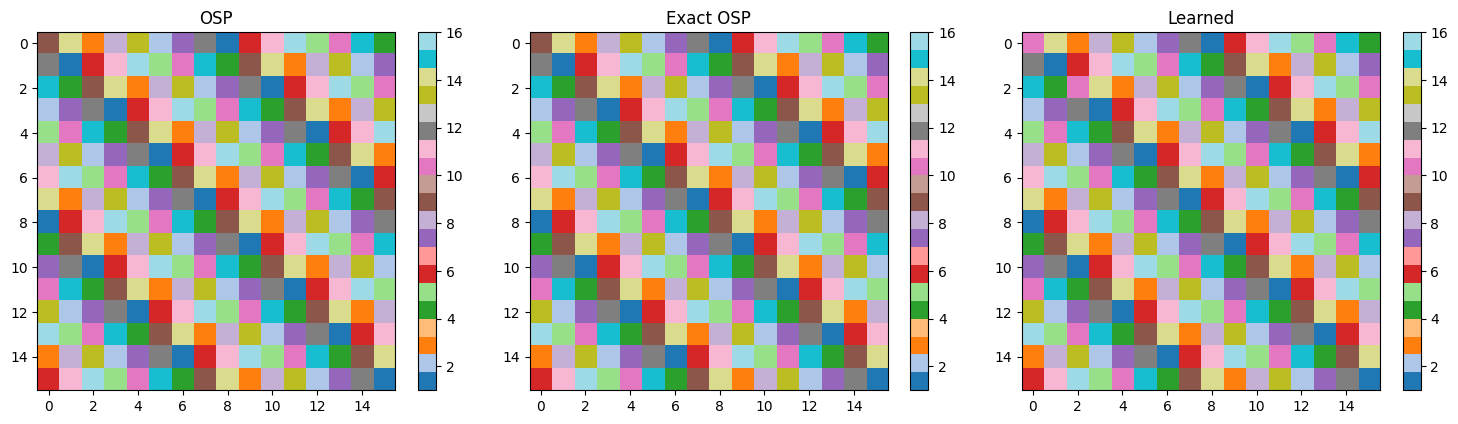

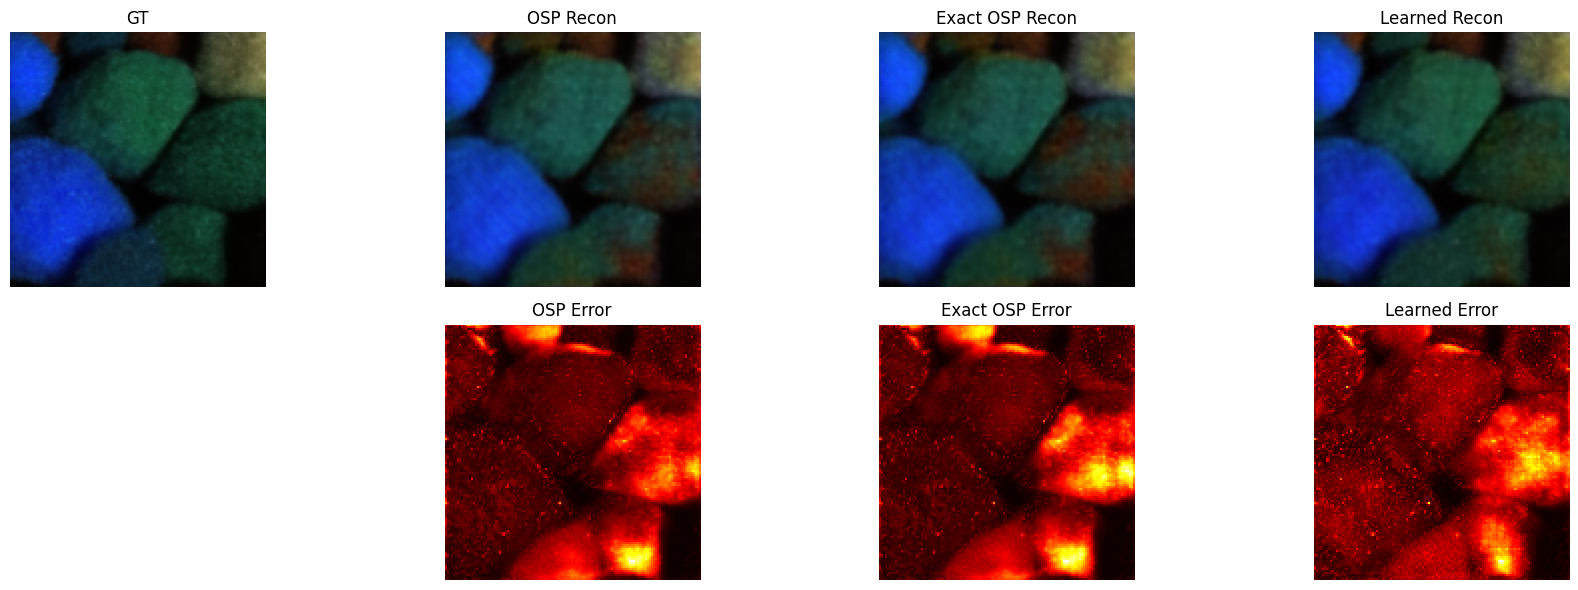

Observation: Learnable outperforms both fixed and exact OSP branches in this setup.


In [ ]:
required_symbols = [
    "torch",
    "np",
    "plt",
    "DEVICE",
    "val_target",
    "val_loader",
    "UNet2D",
    "FixedOSP",
    "OSPSeededLearnableMSFA",
    "evaluate",
    "init_tile_one_based",
    "CKPT_OSP_PATH",
    "CKPT_EXACT_PATH",
    "CKPT_LEARN_PATH",
    "TEMP_END",
    "PRIOR_SCALE_END",
    "FIG_DIR",
]
missing = [name for name in required_symbols if name not in globals()]
if missing:
    raise RuntimeError(
        "Notebook 11 final cell is being run without required setup cells. "
        "Run cells 3 to 6 first. Missing: " + ", ".join(missing)
    )

eval_rows = []
loaded = {}

if CKPT_OSP_PATH.exists():
    osp_ckpt = torch.load(CKPT_OSP_PATH, map_location=DEVICE, weights_only=False)
    osp_model = UNet2D().to(DEVICE)
    osp_model.load_state_dict(osp_ckpt["unet"], strict=True)
    osp_tile_from_ckpt = torch.tensor(osp_ckpt["hard_tile"], dtype=torch.int64)
    osp_msfa = FixedOSP(init_tile_one_based=osp_tile_from_ckpt).to(DEVICE)
    psnr, sam, ssim_val = evaluate(osp_msfa, osp_model, val_loader, mode_name="osp")
    eval_rows.append({"Method": "OSP", "PSNR(dB)": psnr, "SAM(deg)": sam, "RGB-SSIM": ssim_val})
    loaded["osp"] = {"ckpt": osp_ckpt, "model": osp_model, "msfa": osp_msfa}

if CKPT_EXACT_PATH.exists():
    exact_ckpt = torch.load(CKPT_EXACT_PATH, map_location=DEVICE, weights_only=False)
    exact_model = UNet2D().to(DEVICE)
    exact_model.load_state_dict(exact_ckpt["model"], strict=True)
    exact_msfa = FixedOSP(init_tile_one_based=torch.tensor(exact_ckpt["hard_tile"], dtype=torch.int64)).to(DEVICE)
    psnr, sam, ssim_val = evaluate(exact_msfa, exact_model, val_loader, mode_name="osp")
    eval_rows.append({"Method": "Exact OSP", "PSNR(dB)": psnr, "SAM(deg)": sam, "RGB-SSIM": ssim_val})
    loaded["exact"] = {"ckpt": exact_ckpt, "model": exact_model, "msfa": exact_msfa}

if CKPT_LEARN_PATH.exists():
    lrn_ckpt = torch.load(CKPT_LEARN_PATH, map_location=DEVICE, weights_only=False)
    lrn_model = UNet2D().to(DEVICE)
    lrn_model.load_state_dict(lrn_ckpt["unet"], strict=True)
    learn_init_tile = torch.tensor(lrn_ckpt["hard_tile"], dtype=torch.int64)
    lrn_msfa = OSPSeededLearnableMSFA(init_tile_one_based=learn_init_tile).to(DEVICE)
    lrn_msfa.load_state_dict(lrn_ckpt["msfa"], strict=True)
    lrn_temp = lrn_ckpt.get("temperature", TEMP_END)
    lrn_prior = lrn_ckpt.get("prior_scale", PRIOR_SCALE_END)
    psnr, sam, ssim_val = evaluate(lrn_msfa, lrn_model, val_loader, mode_name="learnable", temp=lrn_temp, prior_scale=lrn_prior)
    eval_rows.append({"Method": "Learnable", "PSNR(dB)": psnr, "SAM(deg)": sam, "RGB-SSIM": ssim_val})
    loaded["learnable"] = {"ckpt": lrn_ckpt, "model": lrn_model, "msfa": lrn_msfa, "temp": lrn_temp, "prior": lrn_prior}

if len(eval_rows) == 0:
    print("No checkpoints found. Run training first.")
else:
    print("Final Results")
    print("-" * 64)
    print(f"{'Method':<12} {'PSNR(dB)':>10} {'SAM(deg)':>10} {'RGB-SSIM':>10}")
    print("-" * 64)
    for r in eval_rows:
        print(f"{r['Method']:<12} {r['PSNR(dB)']:>10.3f} {r['SAM(deg)']:>10.3f} {r['RGB-SSIM']:>10.4f}")
    print("-" * 64)

if "osp" in loaded and "exact" in loaded and "learnable" in loaded:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    osp_tile = loaded["osp"]["ckpt"]["hard_tile"]
    exact_tile = loaded["exact"]["ckpt"]["hard_tile"]
    lrn_tile = loaded["learnable"]["ckpt"]["hard_tile"]

    plt.figure(figsize=(15, 4))
    plt.subplot(1, 3, 1)
    plt.title("OSP")
    plt.imshow(osp_tile, cmap="tab20")
    plt.colorbar()
    plt.subplot(1, 3, 2)
    plt.title("Exact OSP")
    plt.imshow(exact_tile, cmap="tab20")
    plt.colorbar()
    plt.subplot(1, 3, 3)
    plt.title("Learned")
    plt.imshow(lrn_tile, cmap="tab20")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "phase11_pattern_comparison.png", dpi=200, bbox_inches="tight")
    plt.show()

    x = torch.from_numpy(val_target[0]).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        osp_pred = loaded["osp"]["model"](loaded["osp"]["msfa"](x)).cpu().numpy()[0]
        exact_pred = loaded["exact"]["model"](loaded["exact"]["msfa"](x)).cpu().numpy()[0]
        lrn_pred = loaded["learnable"]["model"](
            loaded["learnable"]["msfa"](x, temp=loaded["learnable"]["temp"], prior_scale=loaded["learnable"]["prior"])
        ).cpu().numpy()[0]
    gt = x.cpu().numpy()[0]

    gt_rgb = np.transpose(gt[[5, 10, 15]], (1, 2, 0))
    osp_rgb = np.transpose(osp_pred[[5, 10, 15]], (1, 2, 0))
    exact_rgb = np.transpose(exact_pred[[5, 10, 15]], (1, 2, 0))
    lrn_rgb = np.transpose(lrn_pred[[5, 10, 15]], (1, 2, 0))

    def norm01(im):
        mn = im.min()
        mx = im.max()
        return (im - mn) / max(mx - mn, 1e-8)

    gt_rgb = norm01(gt_rgb)
    osp_rgb = norm01(osp_rgb)
    exact_rgb = norm01(exact_rgb)
    lrn_rgb = norm01(lrn_rgb)
    osp_err = np.abs(gt - osp_pred).mean(axis=0)
    exact_err = np.abs(gt - exact_pred).mean(axis=0)
    lrn_err = np.abs(gt - lrn_pred).mean(axis=0)

    plt.figure(figsize=(18, 6))
    plt.subplot(2, 4, 1); plt.title("GT"); plt.imshow(gt_rgb); plt.axis("off")
    plt.subplot(2, 4, 2); plt.title("OSP Recon"); plt.imshow(osp_rgb); plt.axis("off")
    plt.subplot(2, 4, 3); plt.title("Exact OSP Recon"); plt.imshow(exact_rgb); plt.axis("off")
    plt.subplot(2, 4, 4); plt.title("Learned Recon"); plt.imshow(lrn_rgb); plt.axis("off")
    plt.subplot(2, 4, 6); plt.title("OSP Error"); plt.imshow(osp_err, cmap="hot"); plt.axis("off")
    plt.subplot(2, 4, 7); plt.title("Exact OSP Error"); plt.imshow(exact_err, cmap="hot"); plt.axis("off")
    plt.subplot(2, 4, 8); plt.title("Learned Error"); plt.imshow(lrn_err, cmap="hot"); plt.axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "phase11_recon_and_error.png", dpi=200, bbox_inches="tight")
    plt.show()

    osp_row = next(r for r in eval_rows if r["Method"] == "OSP")
    exact_row = next(r for r in eval_rows if r["Method"] == "Exact OSP")
    lrn_row = next(r for r in eval_rows if r["Method"] == "Learnable")
    if (lrn_row["PSNR(dB)"] >= exact_row["PSNR(dB)"]) and (lrn_row["SAM(deg)"] <= exact_row["SAM(deg)"]):
        print("Observation: Learnable outperforms both fixed and exact OSP branches in this setup.")
    elif (exact_row["PSNR(dB)"] >= osp_row["PSNR(dB)"]) and (exact_row["SAM(deg)"] <= osp_row["SAM(deg)"]):
        print("Observation: Exact OSP selection improves the fixed OSP baseline, but learnable remains competitive.")
    else:
        print("Observation: OSP-family methods remain competitive in this setup.")


This notebook now provides the full fair-comparison workflow:
OSP vs learnable with shared loop, logging, evaluation, visualization, and final observations.
